<a href="https://colab.research.google.com/github/NoaTal1996/Backbone-Graph/blob/main/src/key_authors_graph.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Imports

Note: google drive is no longer suppurted. Adjust the input and output path if nedded.

In [11]:
# File System
from pathlib import Path

# ML
import pandas as pd
import numpy as np
from pandas.api.types import is_numeric_dtype

# Plot
import matplotlib.pyplot as plt
from matplotlib_venn import venn3

# TF-IDf
from sklearn.feature_extraction.text import TfidfVectorizer

# Graphs
import networkx as nx
import matplotlib.patches as mpatches

# sklearn
from sklearn.feature_selection import mutual_info_classif

# General
import math
from collections.abc import Iterable
from tqdm import tqdm
from __future__ import annotations



# Loading and Exporting

## Parameters

In [12]:
# dataset_folder = "Labeled_Datasets/Ecuador"   # folder path
# file_name = "Ecuador_part_3.gzip.parquet"  # file name
# dataset_procced_date = "2026_01_08"        # ("%Y_%m_%d")


dataset_folder = "Labeled_Datasets/Ecuador"   # folder path
file_name = "Ecuador_part_all.gzip.parquet"  # file name
dataset_procced_date = "2026_01_10"        # ("%Y_%m_%d")

# Recommended: working directory is: "Backbone-Graph/src"

## Load Data

In [13]:
# Note: Google Colab not supported anymore.

# Cluster\Local
# Recommended: working directory is: "Backbone-Graph/src"
file_name_no_suffixes = file_name.split(".")[0]
processed_dataset_path = Path("../results") / dataset_folder / file_name_no_suffixes / dataset_procced_date
# Example: ""../results/Labeled_Datasets/Ecuador/Ecuador_part_4/2025_11_27"
print(f"Running on local/cluster.\nLoading data from: {processed_dataset_path}")

# Load the parquet file
df = pd.read_parquet(processed_dataset_path / f"processed_{file_name}")

# for testing
# df = df.sample(n = 50).reset_index(drop=True)

Running on local/cluster.
Loading data from: ../results/Labeled_Datasets/Ecuador/Ecuador_part_all/2026_01_10


## Output

In [14]:
folder_output_path = processed_dataset_path # save in the save folder as the processed dataset

# Dataset collums

In [15]:
print
print(f"df shpe: {df.shape}")
print("")
print(f"{'**collum name**':<30} **value type**")
for col in df.columns:
    # dtype_str = str(df[col].dtype)  # Convert dtype to string
    # get a sample non-null value if exists
    sample_val = df[col].dropna().iloc[0] if df[col].notna().any() else None
    print(f"{col:<30} | {type(sample_val).__name__}")

df shpe: (1468565, 24)

**collum name**                **value type**
postid                         | str
post_text                      | str
application_name               | str
post_language                  | str
in_reply_to_postid             | str
in_reply_to_accountid          | str
post_time                      | Timestamp
accountid                      | str
account_profile_description    | str
follower_count                 | int64
following_count                | int64
account_creation_date          | date
is_repost                      | bool
reposted_accountid             | str
reposted_postid                | str
hashtags                       | ndarray
urls                           | ndarray
account_mentions               | ndarray
is_control                     | bool
clean_text_with_entities       | str
clean_text_without_enteties    | str
translated_post                | str
BERTopic_topic_512             | int64
BERTopic_prob512               | float32


In [16]:
account_id_col = "accountid"

Found 1 topic columns:
  - BERTopic_topic_512


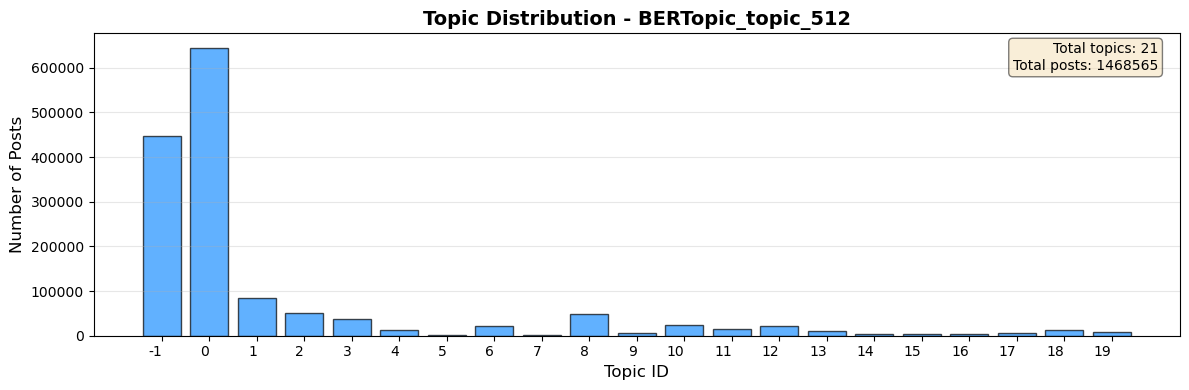


TOPIC DISTRIBUTION SUMMARY

BERTopic_topic_512:
  - Number of unique topics: 21
  - Posts in largest topic: 644,687
  - Posts in smallest topic: 2,150
  - Average posts per topic: 69,932
  - Total posts: 1,468,565


In [17]:
# Find all columns with "BERT", "K_Means", or "topic" in the name (excluding "prob" columns)
topic_columns = [
    col for col in df.columns 
    if any(keyword.lower() in col.lower() for keyword in ["BERT", "K_Means", "topic"])
    and "prob" not in col.lower()
]

# Remove duplicates while preserving order
seen = set()
topic_columns = [col for col in topic_columns if not (col in seen or seen.add(col))]

print(f"Found {len(topic_columns)} topic columns:")
for col in topic_columns:
    print(f"  - {col}")

# Create distribution plots for each topic column
num_cols = len(topic_columns)
fig, axes = plt.subplots(num_cols, 1, figsize=(12, 4 * num_cols))

# Handle case where there's only one column (axes won't be an array)
if num_cols == 1:
    axes = [axes]

for idx, col in enumerate(topic_columns):
    # Count posts per topic
    topic_counts = df[col].value_counts().sort_index()
    
    # Create bar plot
    axes[idx].bar(topic_counts.index, topic_counts.values, color='dodgerblue', edgecolor='black', alpha=0.7)
    axes[idx].set_title(f"Topic Distribution - {col}", fontsize=14, fontweight='bold')
    axes[idx].set_xlabel("Topic ID", fontsize=12)
    axes[idx].set_ylabel("Number of Posts", fontsize=12)
    axes[idx].grid(axis='y', alpha=0.3)
    
    # Set x-ticks to show all topic IDs
    axes[idx].set_xticks(topic_counts.index)
    axes[idx].set_xticklabels(topic_counts.index, rotation=0, ha='right')
    
    # Add count information
    axes[idx].text(0.98, 0.97, f"Total topics: {len(topic_counts)}\nTotal posts: {len(df)}", 
                   transform=axes[idx].transAxes, verticalalignment='top', horizontalalignment='right',
                   bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

# Print summary statistics
print("\n" + "="*60)
print("TOPIC DISTRIBUTION SUMMARY")
print("="*60)
for col in topic_columns:
    topic_counts = df[col].value_counts()
    print(f"\n{col}:")
    print(f"  - Number of unique topics: {len(topic_counts):,}")
    print(f"  - Posts in largest topic: {topic_counts.max():,}")
    print(f"  - Posts in smallest topic: {topic_counts.min():,}")
    print(f"  - Average posts per topic: {topic_counts.mean():,.0f}")
    print(f"  - Total posts: {len(df):,}")

# TF-IDF Score

In [18]:
# prams
topic_col = "BERTopic_topic_512"
entity_cols_lst = ["hashtags", "account_mentions", "urls"] # TODO:add  "ner_entities"

## Entities

TF-IDF Using *sklearn*

In [19]:
def compute_entities_tfidf(df, entity_col, topic_col="BERTopic_topic"):
    """
    Compute TF-IDF over entities grouped by topic.
    Output shape: rows = entities, columns = topics.

    Args:
        df (pd.DataFrame): Contains [topic_col] and [entity_col] (list of entities).
        entity_col (str): Column with lists of entities per post.
        topic_col (str): Topic label column.

    Returns:
        pd.DataFrame: TF-IDF matrix (rows = entities, columns = topics).
    """

    # 1) Explode rows → (topic, entity)
    df_exp = (
        df[[topic_col, entity_col]]
        .explode(entity_col)
        .dropna(subset=[entity_col])
        .astype({entity_col: str})
    )

    # 2) Build topic "documents"
    topic_docs_df = (
        df_exp.groupby(topic_col)[entity_col]
              .apply(lambda x: " ".join(x))
              .reset_index()
              .rename(columns={entity_col: "doc"})
    )

    # 3) TF-IDF where rows=topics, cols=entities
    vec = TfidfVectorizer(token_pattern=r"\S+")
    X = vec.fit_transform(topic_docs_df["doc"])

    topic_entity_df = pd.DataFrame(
        X.toarray(),
        index=topic_docs_df[topic_col].values,
        columns=vec.get_feature_names_out()
    )

    # 4) Transpose → rows=entities, columns=topics
    entity_topic_df = topic_entity_df.T

    return entity_topic_df

In [20]:
hashtags_tfidf_df = compute_entities_tfidf(df, entity_col='hashtags', topic_col=topic_col)
hashtags_tfidf_df.head()

,-1,0,1,2,3,4,5,6,7,8,...,10,11,12,13,14,15,16,17,18,19
#26s,0.0,0.000353,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
#auxilioo,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000184,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
#bestupid,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.000877,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
#boomshakalaka,0.0,0.000176,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
#buenoasi,0.0,0.000176,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [21]:
def get_top_entities(entity_topic_df, topic_id, top_n=10):
    """
    Return a list of the top-N entities for a specific topic.

    Args:
        entity_topic_df (pd.DataFrame):
            Rows = entities, columns = topics ids.
        topic_is (str | int):
            The topic.
        top_n (int):
            Number of top entities.

    Returns:
        list[str]: Top-N entities sorted by descending TF-IDF.
    """

    top_entities = entity_topic_df[topic_id].sort_values(ascending=False).head(top_n).index.tolist()

    return top_entities

In [22]:
top_entities = get_top_entities(hashtags_tfidf_df, topic_id = -1, top_n=10)
print(top_entities)

['elgobiernodetodos', 'agendagubernamental', 'leydecomunicación', 'ecuador', 'cnt', 'rocíodemoreno', 'venezuela', 'leyfomentoproductivo', 'casaparatodos', 'ecuadorendavos']


## Posts

TF-IDF<sub>topic,post</sub> = ∑<sub>entity ∈ post</sub> TF-IDF<sub>topic,entity</sub>

In [23]:
def compute_post_tfidf(
    df: pd.DataFrame,
    topic_col: str,
    entity_cols_lst: list[str],
    out_col: str = "post_tfidf",
) -> None:
    """Compute per-post TF-IDF scores from multiple entity columns.

    Updates df[out_col].
    The TF-IDF score of a posts is the score of its entities in its topic, across all entity columns.

    Args:
        df: Input DataFrame (modified in place).
        topic_col: Column containing topic identifiers.
        entity_cols_lst: List of entity-list columns (each cell is list-like or None).
        out_col: Output column name.

    Returns:
        None.
    """
    df[out_col] = 0.0

    for entity_col in entity_cols_lst:
        # rows=entities, columns=topics
        entities_tfidf_df = compute_entities_tfidf(df, entity_col, topic_col)

        # Build a fast lookup: (entity, topic) -> tfidf
        tfidf_dict = entities_tfidf_df.stack().to_dict()

        for row in tqdm(df.itertuples(index=True), total=len(df), desc=f"Add tf-idf scores of {entity_col}"):
            idx = row.Index
            topic = getattr(row, topic_col)
            ents = getattr(row, entity_col)

            if ents.size == 0: # no entities
                score = 0.0
            else:
                score = float(sum(tfidf_dict.get((e, topic), 0.0) for e in ents))

            df.at[idx, out_col] += score

In [24]:
compute_post_tfidf(df, topic_col, entity_cols_lst)
df[["post_text", "post_tfidf", topic_col]].head()

Add tf-idf scores of urls: 100%|██████████| 1468565/1468565 [02:18<00:00, 10572.77it/s]


,post_text,post_tfidf,BERTopic_topic_512
0,Vamos a cambiar la forma de hacer comunicación...,0.000000,-1
1,"Damos servicio de manejo de prensa, elaboració...",0.000000,-1
2,@db7c47cef2aa2ba68b5c010d761a03fc1c0f0d1302 Bu...,0.000072,0
3,"Mario, debemos denuciar que en los poderes pub...",0.000000,-1
4,Tambien debemos estar claro que la oposición e...,0.000000,-1


## Authors

*(a = author, t= topic, p = post)*

TF<sub>a, t</sub> = ∑ <sub> p ∈ authors's posts in topic</sub> tfidf_score<sub>p, t</sub>

IDF<sub>a</sub> = log((|all_topics| + offset) / (|author's_topics| + offset))

TF-IDF<sub>a,t</sub> = TF<sub>a, t</sub> * IDF<sub>a</sub>

In [25]:
def compute_author_tfidf_to_df(
    df: pd.DataFrame,
    topic_col: str = "BERTopic_topic",
    author_col: str = "accountid",
    post_score_col: str = "post_tfidf",
    out_col: str = "topic_author_tfidf",
    use_log_idf: bool = True,
    idf_offset: float = 1.0,
    folder_output_path: Path = None,
) -> pd.DataFrame:
    """Compute author–topic TF-IDF and write each post's score to df.

    TF = sum of post scores per (author, topic).
    IDF = penalizes authors active in many topics.
    Output column contains TF-IDF(author, topic) for each post.

    Args:
        df: Input DataFrame with posts.
        topic_col: Topic column name.
        author_col: Author column name.
        post_score_col: Per-post score column.
        out_col: Output column added to df.
        use_log_idf: Apply log to IDF.
        idf_offset: Smoothing constant.
        folder_output_path: If given, save the author-topic TF-IDF matrix to this path.

    Returns:
        author_topic_tfidf: Author × topic TF-IDF matrix.
    """

    # TF matrix: rows = authors, columns = topics, values = tf score
    author_topic_tf = (
        df.groupby([author_col, topic_col])[post_score_col]
        .sum()
        .unstack(fill_value=0)
    )

    # IDF per author
    n_topics = author_topic_tf.shape[1]
    topics_per_author = (author_topic_tf > 0).sum(axis=1)
    idf = (n_topics + idf_offset) / (topics_per_author + idf_offset)
    if use_log_idf:
        idf = np.log(idf)

    # TF-IDF matrix
    author_topic_tfidf = author_topic_tf.mul(idf, axis=0)

    # Assign TF-IDF(author, topic) to each post
    df[out_col] = df.apply(
        # Pandas aligns by row index = author.
        lambda row: author_topic_tfidf.loc[row[author_col], row[topic_col]],
        axis=1,
    )

    # save
    if folder_output_path is not None:
        author_topic_tfidf.to_parquet(folder_output_path / f"author_topic_tfidf_by_{topic_col}.parquet", compression="gzip")

    return author_topic_tfidf

In [26]:
author_topic_tfidf = compute_author_tfidf_to_df(df, topic_col = topic_col, folder_output_path=folder_output_path)
author_topic_tfidf.head()

BERTopic_topic_512,-1,0,1,2,3,4,5,6,7,8,...,10,11,12,13,14,15,16,17,18,19
accountid,,,,,,,,,,,,,,,,,,,,,
0002e64fc6035627e87f8312ee9c8c0098b1d6cd2a,0.002283,0.011324,0.000000,0.000000,0.000000,0.000000,0.0,0.00000,0.0,0.000000,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0
0005c5f571ae94a562ab590fbcab9138cee6d20507,0.000000,0.000187,0.000000,0.001725,0.004333,0.000000,0.0,0.00368,0.0,0.000392,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0
0007a45e37da6ae559d6b4b76218874d6ab677234b,0.012664,0.208369,0.000000,0.000000,0.000000,0.000000,0.0,0.00000,0.0,0.000000,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0
000fca065490ad68fbb646d9491061b2abd861703f,0.000000,0.007914,0.000000,0.000000,0.001968,0.000000,0.0,0.00000,0.0,0.006284,...,0.000524,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.046191,0.0
0011cb6aa969ab7bc4359a6c445287ca0671aac4c0,0.008327,0.045486,0.004534,0.000000,0.000000,0.010886,0.0,0.00000,0.0,0.000000,...,0.439300,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0


# Key Authors

In [27]:
def get_topic_top_authors(
    df: pd.DataFrame,
    topic: str | int,
    score_col: str = "topic_author_tfidf",
    author_col: str = "accountid",
    topic_col: str = "BERTopic_topic",
    n: int = 100,
) -> set:
    """Return the top-n authors for a given topic based on author-topic scores.

    The author-topic score is assumed to be precomputed. Each author is
    considered once per topic; repeated posts do not increase the score.

    Args:
        df: DataFrame containing posts with author-topic scores.
        topic: Topic to extract top authors for.
        score_col: Column storing author-topic scores.
        author_col: Column storing author identifiers.
        topic_col: Column storing topic labels.
        n: Number of top authors to return.

    Returns:
        set: Authors ranked in the top-n for the given topic.
    """
    top_authors = (
        df.loc[df[topic_col] == topic, [author_col, score_col]]
        .dropna(subset=[author_col, score_col])
        .drop_duplicates(author_col)     # one row per author
        .sort_values(score_col, ascending=False)
        .head(n)[author_col]
    )

    topic_key_authors = set(top_authors)

    print(f"There are {len(topic_key_authors)} unique key authors in topic {topic}.")

    return topic_key_authors

In [28]:
get_topic_top_authors(df, topic=1, topic_col = topic_col)

There are 100 unique key authors in topic 1.


{'0080b858dcdf930f1029c57f65491e8df51b3bebc5',
 '01769a6a8c78cbbe38511b30c649e3b9a69acd7287',
 '01b0efdd37579f669eb5435ed1d747feced02e4b53',
 '076e32ebd660b01a866cc68f2fc6e723ca15050a3c',
 '0a8807d5066f19a69e7b28d0652c13320f3b7063b0',
 '0d3b88567bf65211bb328ab87185c347edd4f29f9a',
 '11147ad7649a0fccc3dea617a5e495894df11926d8',
 '123e97476d70378a4e1b523764a0e85feab6d4d5d4',
 '13512f0d9a07cecb53b90bfc2856495eb6e40a0036',
 '16aca549f0d8b48551a690d1033c216e6714ef9de5',
 '18a85c6353e0f14a67e79c858ac310d2a556fcd76e',
 '1b6af2310644a99d47f9866e046d675a7fc9a8d667',
 '1d6a261276b5eb20a1e13ddb1ece2bc8d3a30bb4c0',
 '1ffd546573448d5ac5ba1dbabd85c087663f24f29f',
 '20c84908f721f66d4339e7ac676d47d6a57ac47fb7',
 '232f1abccf35b0cb5b49140d0e9299af60eff89aa8',
 '23d9d97d91127cb7b65b973df67d2e88cb2143500d',
 '24aa1d4c2a5ac62f28e623121cb8dea96209871f94',
 '29c56783516c3f07f96b1674fc5ef3f7e779c13b9d',
 '2a7c9b76f19655b08619adb2970792d63beedb7b0f',
 '2ec167b0422835075f161c87529f45b5e9dcb96848',
 '305856c24fb

In [29]:
def get_all_topics_key_authors(
    df: pd.DataFrame,
    score_col: str = "topic_author_tfidf",
    author_col: str = "accountid",
    topic_col: str = "BERTopic_topic",
    top_n: int = 10,
) -> tuple[pd.DataFrame, set]:
    """Return a set of authors that are top-n in at least one topic.

    Args:
        df: DataFrame with author-topic TF-IDF scores.
        score_col: Column storing TF-IDF(author, topic).
        author_col: Column storing author IDs.
        topic_col: Column storing topic labels.
        top_n: Top-n authors per topic.

    Returns:
        pd.DataFrame: DataFrame of key authors per topic [topic_col, author_col, score_col].
        set: Authors that appear in the top-n of any topic.
    """
    all_topics_key_authors_df = (
        df[[topic_col, author_col, score_col]]
        .dropna(subset=[topic_col, author_col, score_col])
        .drop_duplicates([topic_col, author_col])   # no aggregation
        .sort_values([topic_col, score_col], ascending=[True, False])
        .groupby(topic_col)
        .head(top_n)
        .reset_index(drop=True)
    )

    print("Sample of all topic key authors:")
    print("Note: authors may appear multiple times for different topics.")
    display(all_topics_key_authors_df.sample(n=10))

    all_topic_top_authors_number = all_topics_key_authors_df.drop_duplicates(subset=[author_col]).shape[0]
    print(f"There are {all_topic_top_authors_number} unique key authors in all topics.")
    
    return all_topics_key_authors_df, set(all_topics_key_authors_df[author_col])

In [30]:
all_topics_key_authors_df, all_topics_key_authors_set = get_all_topics_key_authors(df = df, topic_col = topic_col, top_n = 5)

Sample of all topic key authors:
Note: authors may appear multiple times for different topics.


,BERTopic_topic_512,accountid,topic_author_tfidf
101,19,2757a5b186748342bdb2a72618699a09bda3477423,121.065373
2,-1,71b45b9cfbe033acf94c15763207cc9f35746ad22a,1052.460666
70,13,a7b965c1b1bf78ef15777fd79926127244502d53e2,78.919564
26,4,ddf8ec7fce6f33390623fc8f1f4cd0ba42a0b6d9ce,239.540522
17,2,25301cb7412d7f21916f09d00b7e4ca0d7221885d5,89.102175
91,17,068f4423782e48a629db8d0c352b247a3fba96d1df,34.157390
22,3,5a92b4fbaaa2dad5f57877a8b60c74f9f1f350a68e,23.069729
46,8,12be7473fa65181f7964e9adfdbd303cb96edceabb,117.767951
19,2,386f0709bb79b9110b3bb2d49c2bae0f285957b681,12.074711
9,0,440b1c559801cd55ec511a956c82f76bca5b828f71,150.444079


There are 93 unique key authors in all topics.


# IO Authors

In [31]:
def get_io_authors_by_ratio(
    df: pd.DataFrame,
    author_col: str = "accountid",
    is_io_control_col: str = "is_control",
    io_threshold: float = 0.33,
    min_posts: int = 5,
) -> set:
    """Return authors classified as IO based on IO-post ratio.

    Args:
        df: Posts DataFrame.
        author_col: Column with author IDs.
        is_io_control_col: Column where 1=control (non-IO), 0=IO.
        io_threshold: Minimum IO ratio to tag an author as IO.
        min_posts: Minimum number of posts per author.

    Returns:
        set: Author IDs tagged as IO.
    """
    grouped = df.groupby(author_col)[is_io_control_col]

    author_stats = pd.DataFrame({
        "total_posts": grouped.count(),
        "io_ratio": 1 - grouped.mean(),
    })

    io_authors = set(
        author_stats[
            (author_stats["total_posts"] >= min_posts)
            & (author_stats["io_ratio"] >= io_threshold)
        ].index
    )

    print(f"There are {len(io_authors)} io authors.")

    return io_authors

In [32]:
io_authors_set = get_io_authors_by_ratio(df)

There are 711 io authors.


# Key and IO Authors

## Summary

In [33]:
def save_and_print_io_key_summary(
    df,
    io_authors_set,
    all_topics_key_authors_set,
    output_path: str | Path,
    author_col: str = "accountid",
):
    """Print and save summary statistics for IO / key authors."""

    both_io_and_key = io_authors_set & all_topics_key_authors_set
    pct_io_also_key = (len(both_io_and_key) / len(io_authors_set) * 100 if len(io_authors_set) > 0 else 0)

    all_authors_set = set(df[author_col].astype(str).drop_duplicates())

    summary_text = (
        "### io_key_summary ###\n"
        "\n"
        f"Number of all authors: {len(all_authors_set)}\n"
        "\n"
        f"Number of IO authors: {len(io_authors_set)}\n"
        f"Number of key authors: {len(all_topics_key_authors_set)}\n"
        "\n"
        f"Number of authors that are both IO and key: {len(both_io_and_key)}\n"
        f"{pct_io_also_key:.1f}% of IO authors are also key authors\n"
    )

    # print to console
    print(summary_text)

    # save to text file
    output_path = Path(output_path)
    summary_file_path = output_path / "io_key_authors_summary.txt"
    with open(summary_file_path, "w", encoding="utf-8") as f:
        f.write(summary_text)

    print(f"Saved summary to: {summary_file_path}")

    return None

In [34]:
save_and_print_io_key_summary(df = df, io_authors_set = io_authors_set, all_topics_key_authors_set = all_topics_key_authors_set, output_path = folder_output_path)

### io_key_summary ###

Number of all authors: 21923

Number of IO authors: 711
Number of key authors: 93

Number of authors that are both IO and key: 22
3.1% of IO authors are also key authors

Saved summary to: ../results/Labeled_Datasets/Ecuador/Ecuador_part_all/2026_01_10/io_key_authors_summary.txt


## Venn Plot

In [35]:
def plot_venn_3_sets(
    all_authors_set: set,
    all_topics_key_authors_set: set,
    io_authors_set: set,
    title: str = "Venn diagram",
    set_labels: tuple[str, str, str] = ("All authors", "Key authors", "IO authors"),
    folder_output_path: str | Path = None,
) -> None:
    """Plot a 3-set Venn diagram for author subsets.

    Args:
        all_authors_set: Set of all author IDs in the dataset/graph.
        all_topics_key_authors_set: Set of authors selected as key-authors across topics.
        io_authors_set: Set of IO-labeled authors.
        title: Figure title.
        set_labels: Labels for the three sets (A, B, C) in the diagram.
    """
    # Normalize to strings for consistent overlap
    A = set(map(str, all_authors_set))
    B = set(map(str, all_topics_key_authors_set))
    C = set(map(str, io_authors_set))

    plt.figure(figsize=(7, 6))
    venn3(subsets=(A, B, C), set_labels=set_labels)
    plt.title(title)
    plt.tight_layout()


    # Save figure
    if folder_output_path is not None:
      folder_output_path = Path(folder_output_path)
      plt.savefig(folder_output_path / "venn.png", dpi=300)
      print(f"Saved fig to: {file_path}")

    plt.show()
    plt.close()

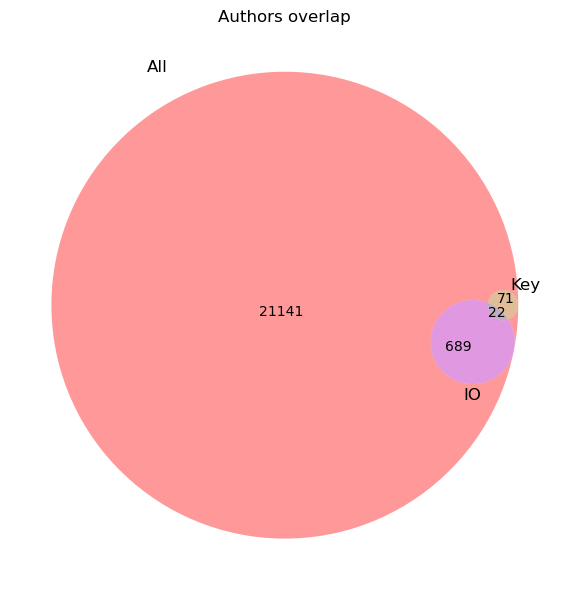

In [36]:
# Compute all authors set
all_authors_set = set(df[account_id_col].astype(str).drop_duplicates())

plot_venn_3_sets(
    all_authors_set=all_authors_set,
    all_topics_key_authors_set=all_topics_key_authors_set,
    io_authors_set=io_authors_set,
    title="Authors overlap",
    set_labels=("All", "Key", "IO"),
)

# Networkx Graphs

## Parameters

In [37]:
account_relations = [
    ("accountid", "in_reply_to_accountid"),
    ("accountid", "account_mentions"),
    ("accountid", "reposted_accountid"),
]

## Build Bipartite Account ↔ Account Graph

In [38]:
def add_relation_edges(
    G: nx.Graph,
    df: pd.DataFrame,
    src_col: str,
    dst_col: str,
    weight: int = 1,
    ignore_self_loops: bool = True,
    all_topics_key_authors_df: pd.DataFrame | None = None,
    author_col: str = "accountid",
    score_col: str = "topic_author_tfidf",
    topic_col: str = "BERTopic_topic",
    io_authors: set | None = None,
) -> None:
    """Add weighted edges to a graph and annotate author nodes.

    This builds edges from co-occurrence counts of (src, dst) pairs.
    Edge weights are incremented by `weight` for each co-occurrence.
    Annotates nodes with: (optional)
        * io_author: 1 if author in `io_authors`, else 0
        * score: aggregated author-topic score 
        * participan_at_topics: list of topics the author is active in
      

    Args:
        G: Target NetworkX graph.
        df: DataFrame containing relation columns.
        src_col: Source column name (scalar or list-like).
        dst_col: Destination column name (scalar or list-like).
        weight: Multiplier applied to counted co-occurrences.
        ignore_self_loops: If True, drops rows where src == dst.
        all_topics_key_authors_df: Optional DataFrame with author-topic metadata.
        author_col: Column in `all_topics_key_authors_df` containing author IDs.
        score_col: Column in `all_topics_key_authors_df` containing author-topic score.
        topic_col: Column in `all_topics_key_authors_df` containing topic label.
        io_authors: Optional set of IO-labeled authors.

    Returns:
        None
    """

    # make pairs of src-dst
    pairs = df[[src_col, dst_col]].dropna()
    pairs = pairs.explode(src_col).dropna(subset=[src_col])
    pairs = pairs.explode(dst_col).dropna(subset=[dst_col])
    pairs[src_col] = pairs[src_col].astype(str)
    pairs[dst_col] = pairs[dst_col].astype(str)

    if ignore_self_loops:
        pairs = pairs[pairs[src_col] != pairs[dst_col]]

    # author_meta: (score_map, topics_map)
    author_meta = None
    if all_topics_key_authors_df is not None:
        tmp = all_topics_key_authors_df[[author_col, score_col, topic_col]].dropna()
        tmp[author_col] = tmp[author_col].astype(str)

        key = set(tmp[author_col].unique())
        pairs = pairs[pairs[src_col].isin(key) & pairs[dst_col].isin(key)]

        # score per author
        author_sum_score_map: dict[str, float] = tmp.groupby(author_col)[score_col].sum().to_dict()
        # Topics per author, sorted by score descending (highest-score topics first)
        author_topics_map : dict[str, list] = (
            tmp.sort_values([author_col, score_col], ascending=[True, False])
            .groupby(author_col)[topic_col]
            .apply(list)
            .to_dict()
        )
        
        author_meta = (author_sum_score_map , author_topics_map)

    # io_author set
    if io_authors is not None:
        io_authors = set(map(str, io_authors))


    counts = pairs.value_counts([src_col, dst_col]).reset_index(name="count")
    print("pairs.value_counts head:")
    display(counts.head())

    for row in counts.itertuples(index=False):
        src = getattr(row, src_col)
        dst = getattr(row, dst_col)
        w = int(row.count) * weight

        # Add or update edge weight
        if G.has_edge(src, dst):
            G[src][dst]["weight"] += w
            continue # skip to next row, dont update labels again

        # add the edge (automatically add nodes if needed)
        G.add_edge(src, dst, weight=w)
            
        # add lables
        for author in [src, dst]:
            # add io_author label
            if io_authors is not None:
                G.nodes[author]["io_author"] = int(author in io_authors)
            # add author meta
            if author_meta is not None:

                G.nodes[author][f"all_topics_scores_sum"] = author_meta[0][author]

                author_topics = author_meta[1][author]
                G.nodes[author]["highest_score_topic"] = author_topics[0] # the topic with the highest score
                G.nodes[author]["participan_at_topics"] = ",".join(map(str, author_topics))
                
    return None

In [39]:
def build_accounts_graph(
    df: pd.DataFrame,
    account_relations: list[tuple[str, str]],
    io_authors: set | None = None,
    all_topics_key_authors_df: pd.DataFrame | None = None,
    output_path: Path | None = None,
    topic_col: str = "BERTopic_topic_512",
    is_directed_graphs: bool = True,
) -> nx.Graph:
    """Build a directed accounts interaction graph and optionally export to GEXF.

    Args:
        df: Posts DataFrame.
        account_relations: List of (src_col, dst_col) relations. Columns must exist in df.
        io_authors: Set of IO authors (used to tag nodes).
        all_topics_key_authors_df: Optional filter for key authors onlya (author-topic metadata).
        output_path: If provided, writes `<output_path>/<topic_col>_accounts_graph.gexf`.
        is_directed_graphs (bool): If True, use a directed graph (nx.DiGraph); otherwise use an undirected graph (nx.Graph).
        topic_col: Topic column name (used in add_relation_edges).


    Returns:
        nx.DiGraph: The constructed accounts graph.
    """
    # create graph
    if is_directed_graphs:
        G = nx.DiGraph()
    else:
        G = nx.Graph()

    # Set graph name (exported to GEXF)
    G.graph["name"] = f"{topic_col}_accounts_graph"

    # User Warnings
    if io_authors is None:
        print("Warning: io_authors is None. No nodes will be tagged as io_author.")
    if all_topics_key_authors_set is None:
        print("Warning: all_topics_key_authors_set is None. No filtering will be applied.")

    # Add nodes and edges
    for src_col, dst_col in account_relations:
        print(f"[build_accounts_graph] Now adding edges of {dst_col}")
        add_relation_edges(
            G,
            df,
            src_col=src_col,
            dst_col=dst_col,
            weight=1,
            ignore_self_loops=True,
            all_topics_key_authors_df=all_topics_key_authors_df,
            io_authors=io_authors,
            topic_col = topic_col,
        )

    # Save
    if output_path is not None:
        graph_output_path = output_path / f"{topic_col}_accounts_graph.gexf"
        nx.write_gexf(G, graph_output_path)
        print(f"Saved graph to: {graph_output_path}")

    return G

In [40]:
G_accounts = build_accounts_graph(
    df=df,
    account_relations=account_relations,
    io_authors=io_authors_set,
    all_topics_key_authors_df=all_topics_key_authors_df,
    output_path=folder_output_path,
    topic_col="BERTopic_topic_512",
)

[build_accounts_graph] Now adding edges of in_reply_to_accountid
pairs.value_counts head:


,accountid,in_reply_to_accountid,count
0,71f8326cc25135b9f8c10b8484a1e482e92443c810,a7b965c1b1bf78ef15777fd79926127244502d53e2,21
1,a7b965c1b1bf78ef15777fd79926127244502d53e2,71f8326cc25135b9f8c10b8484a1e482e92443c810,20
2,e6ae19dca4a4a77e9208543bb0138b888448354d7a,71f8326cc25135b9f8c10b8484a1e482e92443c810,7
3,71b45b9cfbe033acf94c15763207cc9f35746ad22a,9438f9fc6a1d881a2e9e390a1fe8717dec08f6b115,3
4,a7b965c1b1bf78ef15777fd79926127244502d53e2,33461cd78e23ac28bdfd3216ac29c423cff776e020,2


[build_accounts_graph] Now adding edges of account_mentions
pairs.value_counts head:


,accountid,account_mentions,count
0,71f8326cc25135b9f8c10b8484a1e482e92443c810,33461cd78e23ac28bdfd3216ac29c423cff776e020,572
1,a7b965c1b1bf78ef15777fd79926127244502d53e2,71f8326cc25135b9f8c10b8484a1e482e92443c810,515
2,a7b965c1b1bf78ef15777fd79926127244502d53e2,33461cd78e23ac28bdfd3216ac29c423cff776e020,510
3,71f8326cc25135b9f8c10b8484a1e482e92443c810,82ce154453de7868708224343bc1119b35e4a9094c,430
4,71f8326cc25135b9f8c10b8484a1e482e92443c810,a7b965c1b1bf78ef15777fd79926127244502d53e2,410


[build_accounts_graph] Now adding edges of reposted_accountid
pairs.value_counts head:


,accountid,reposted_accountid,count
0,a7b965c1b1bf78ef15777fd79926127244502d53e2,71f8326cc25135b9f8c10b8484a1e482e92443c810,93
1,9438f9fc6a1d881a2e9e390a1fe8717dec08f6b115,71b45b9cfbe033acf94c15763207cc9f35746ad22a,87
2,71b45b9cfbe033acf94c15763207cc9f35746ad22a,9438f9fc6a1d881a2e9e390a1fe8717dec08f6b115,74
3,71f8326cc25135b9f8c10b8484a1e482e92443c810,a7b965c1b1bf78ef15777fd79926127244502d53e2,68
4,c0ec4670482f72aff08d96386651468fdb9494bb5f,718633c01af2bd9c2435764721d961a6ae113dec92,58


Saved graph to: ../results/Labeled_Datasets/Ecuador/Ecuador_part_all/2026_01_10/BERTopic_topic_512_accounts_graph.gexf


## Plot Accounts Graph

In [41]:
def plot_accounts_graph(
    G: nx.Graph,
    folder_output_path: str | Path | None = None,
    graph_name: str = "accounts_graph",
    figsize: tuple = (12, 12),
    key_authors: set | Iterable | None = None,
    layout: str = "spring",
):
    """Plot a NetworkX graph and highlight IO authors.
    
    Args:
        G: Input NetworkX graph with node attribute 'io_author' (1 for IO, 0 for non-IO).
        folder_output_path: If provided, saves the plot to this folder.
        graph_name: Base name for the saved plot file.
        figsize: Figure size for the plot.
        key_authors: If provided, only plot the subgraph induced by these authors.
        layout: Layout algorithm from NetworkX. Options: 'spring', 'circular', 'random', 'shell', 'spectral', 'kamada_kawai'
    """
    if key_authors is not None:
        key_authors = set(map(str, key_authors))
        G_plot = G.subgraph(key_authors)
    else:
        G_plot = G

    n_nodes = G_plot.number_of_nodes()
    n_io = sum(1 for n in G_plot.nodes if G_plot.nodes[n].get("io_author", 0) == 1)
    n_legitimate = n_nodes - n_io
    
    print(f"Plotting graph with {n_nodes} nodes: {n_io} IO authors, {n_legitimate} legitimate authors")
    
    plt.figure(figsize=figsize)
    
    # Choose layout
    if layout == "spring":
        pos = nx.spring_layout(G_plot, seed=42)
    elif layout == "circular":
        pos = nx.circular_layout(G_plot)
    elif layout == "random":
        pos = nx.random_layout(G_plot, seed=42)
    elif layout == "shell":
        pos = nx.shell_layout(G_plot)
    elif layout == "spectral":
        pos = nx.spectral_layout(G_plot)
    elif layout == "kamada_kawai":
        pos = nx.kamada_kawai_layout(G_plot)
    else:
        raise ValueError(f"Unknown layout: {layout}")

    node_colors = [
        "red" if G_plot.nodes[n].get("io_author", 0) == 1 else "steelblue"
        for n in G_plot.nodes
    ]

    nx.draw(
        G_plot,
        pos,
        node_size=30,
        node_color=node_colors,
        edge_color="gray",
        width=0.5,
        alpha=0.8,
        with_labels=False,
    )

    legend_elements = [
        mpatches.Patch(color="steelblue", label=f"Non-IO author ({n_legitimate} nodes)"),
        mpatches.Patch(color="red", label=f"IO author ({n_io} nodes)"),
    ]
    plt.legend(handles=legend_elements, loc="upper right", frameon=True, fontsize=10)

    if folder_output_path is not None:
        plot_path = Path(folder_output_path) / f"{graph_name}_{layout}.png"
        plt.savefig(plot_path, dpi=300, bbox_inches="tight")
        print(f"Saved graph to: {plot_path}")

    plt.show()
    plt.close()


Plotting graph with 17 nodes: 10 IO authors, 7 legitimate authors
Saved graph to: ../results/Labeled_Datasets/Ecuador/Ecuador_part_all/2026_01_10/BERTopic_topic_512_accounts_graph_spring.png


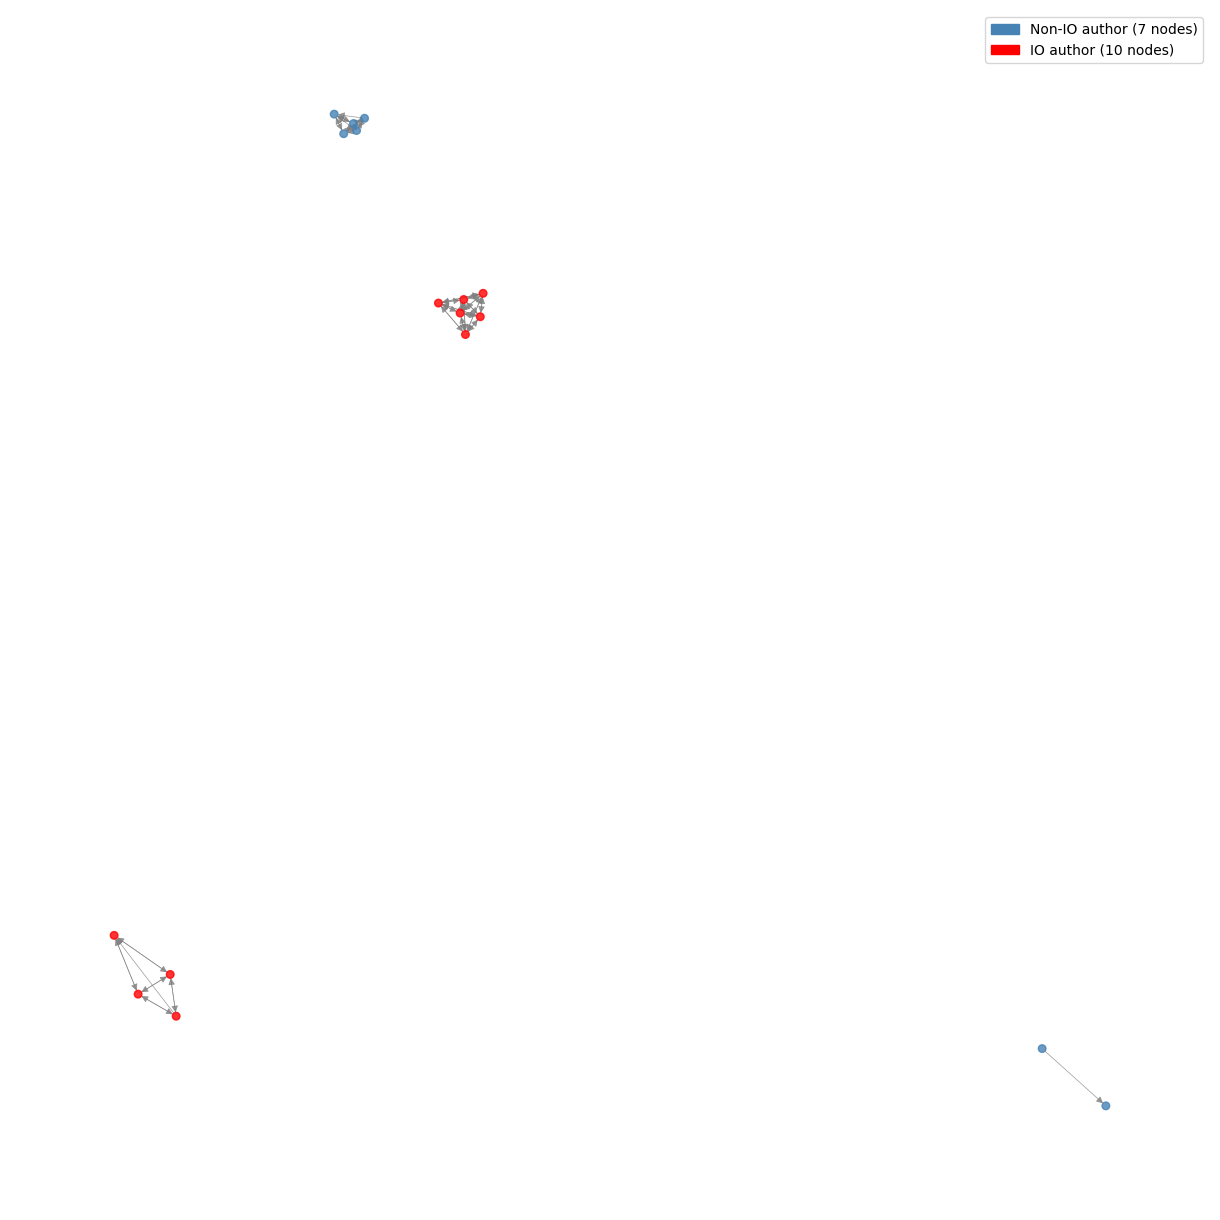

In [42]:
# Layout Options: 'spring', 'circular', 'random', 'shell', 'spectral', 'kamada_kawai'
plot_accounts_graph(G = G_accounts, folder_output_path = folder_output_path, graph_name = f"{topic_col}_accounts_graph", layout="spring")

# IO Indicators

e.g, centralities, core number

## Compute Indicators

In [43]:
def compute_indicators(G: nx.Graph, output_folder_path: str | Path | None = None) -> pd.DataFrame:
    """Compute multiple graph centralities.

    Returns a DataFrame indexed by author/node with:
      - degree
      - betweenness
      - closeness
      - eigenvector
      - pagerank
      - kcore (core number)
      - sum tfidf score

    Args:
        G: NetworkX graph

    Returns:
        centralities_df: Centrality measures per node.
    """
    # Degree centrality
    print("Calculating: degree_centrality")
    degree = nx.degree_centrality(G)
    

    # Betweenness centrality
    print("Calculating: betweenness_centrality")
    betweenness = nx.betweenness_centrality(G, normalized=True)
    

    # Closeness centrality
    print("Calculating: closeness_centrality")
    closeness = nx.closeness_centrality(G)

    # Harmonic centrality
    print("Calculating: harmonic_centrality")
    harmonic = nx.harmonic_centrality(G)

    # Load centrality
    print("Calculating: load_centrality")
    load = nx.load_centrality(G, normalized=True)

    # Eigenvector centrality
    print("Calculating: eigenvector_centrality")
    eigen = nx.eigenvector_centrality(G, max_iter=2000)
    

    # PageRank
    print("Calculating: pagerank")
    pagerank = nx.pagerank(G)

    # Clustering
    print("Calculating: clustering")
    clustering = nx.clustering(G)


    # K-core number
    print("Calculating: core_number")
    kcore = nx.core_number(G)

    # sum tfidf score
    print("Calculating: all_topics_scores_sum")
    all_topics_scores_sum: dict[str, float] = {
    node: G.nodes[node]["all_topics_scores_sum"]
    for node in G.nodes
}

    # Build DataFrame
    node_indicators_df = pd.DataFrame(
        {
            "degree_centrality": degree,
            "betweenness_centrality": betweenness,
            "closeness_centrality": closeness,
            "harmonic_centrality": harmonic,
            "eigenvector_centrality": eigen,
            "load_centrality": load,
            "pagerank": pagerank,
            "kcore": kcore,
            "clustering": clustering,
            "all_topics_scores_sum": all_topics_scores_sum,
        }
    )

    node_indicators_df.index.name = "accountid"


    if output_folder_path is not None:
        node_indicators_df_path = Path(output_folder_path) / "node_centralities.parquet"
        node_indicators_df.to_parquet(node_indicators_df_path, index=True, compression="gzip")
        print(f"node_indicators_df is saved to: {node_indicators_df_path}")


    return node_indicators_df

In [44]:
node_indicators_df = compute_indicators(G_accounts)
node_indicators_df.head()

Calculating: degree_centrality
Calculating: betweenness_centrality
Calculating: closeness_centrality
Calculating: harmonic_centrality
Calculating: load_centrality
Calculating: eigenvector_centrality
Calculating: pagerank
Calculating: clustering
Calculating: core_number
Calculating: all_topics_scores_sum


,degree_centrality,betweenness_centrality,closeness_centrality,harmonic_centrality,eigenvector_centrality,load_centrality,pagerank,kcore,clustering,all_topics_scores_sum
accountid,,,,,,,,,,
71f8326cc25135b9f8c10b8484a1e482e92443c810,0.500,0.016667,0.250000,4.0,0.000006,0.016667,0.102926,6,0.666667,537.543386
a7b965c1b1bf78ef15777fd79926127244502d53e2,0.375,0.000000,0.166667,3.0,0.000003,0.000000,0.040308,6,0.846154,787.936967
e6ae19dca4a4a77e9208543bb0138b888448354d7a,0.375,0.000000,0.166667,3.0,0.000003,0.000000,0.021355,6,0.846154,425.684597
71b45b9cfbe033acf94c15763207cc9f35746ad22a,0.625,0.000000,0.312500,5.0,0.408248,0.000000,0.126335,10,1.000000,1247.645465
9438f9fc6a1d881a2e9e390a1fe8717dec08f6b115,0.625,0.000000,0.312500,5.0,0.408248,0.000000,0.128647,10,1.000000,1909.290910


## Z-Score

In [45]:
def zscore_from_series(values_series: pd.Series, ddof: int = 0) -> pd.Series:
    """Compute z-score normalization for a pandas Series.
    Args:
        s: Input series.
        ddof: Delta degrees of freedom for std (0=population, 1=sample).
    Returns:
        Z-scored series (same index).
    """
    mean = values_series.mean()
    std = values_series.std(ddof=ddof)

    if std == 0 or pd.isna(std):
        return pd.Series(0.0, index=values_series.index, name=f"{values_series.name}_z_score")

    return ((values_series - mean) / std).rename(f"{values_series.name}_z_score")


In [46]:
def compute_zscore(node_indicators_df : pd.DataFrame) -> pd.DataFrame:
    """Compute z-score normalization for all columns in a DataFrame.

    Args:
        node_indicators_df: Input DataFrame with numeric columns.

    Returns:
        zscore_df: DataFrame with z-scored columns.
    """
    
    zscore_df = pd.DataFrame()

    for col in node_indicators_df.columns:
        zscore_df[f"{col}"] = zscore_from_series(node_indicators_df[col])

    zscore_df.index = node_indicators_df.index

    zscore_df.index.name = "accountid"

    return zscore_df

In [47]:
node_indicators_zscore_df = compute_zscore(node_indicators_df)
print("#### zscore ####")
node_indicators_zscore_df.head()

#### zscore ####


,degree_centrality,betweenness_centrality,closeness_centrality,harmonic_centrality,eigenvector_centrality,load_centrality,pagerank,kcore,clustering,all_topics_scores_sum
accountid,,,,,,,,,,
71f8326cc25135b9f8c10b8484a1e482e92443c810,0.409273,3.941351,0.338112,0.307729,-0.738529,3.941351,1.188611,-0.202031,-0.453322,-0.097993
a7b965c1b1bf78ef15777fd79926127244502d53e2,-0.286491,-0.312806,-0.572448,-0.389790,-0.738546,-0.312806,-0.499003,-0.202031,0.126735,0.370713
e6ae19dca4a4a77e9208543bb0138b888448354d7a,-0.286491,-0.312806,-0.572448,-0.389790,-0.738546,-0.312806,-1.009815,-0.202031,0.126735,-0.307379
71b45b9cfbe033acf94c15763207cc9f35746ad22a,1.105036,-0.312806,1.021032,1.005247,1.354006,-0.312806,1.819514,1.171777,0.623926,1.231231
9438f9fc6a1d881a2e9e390a1fe8717dec08f6b115,1.105036,-0.312806,1.021032,1.005247,1.354006,-0.312806,1.881817,1.171777,0.623926,2.469751


## Account Indicators Summery

In [48]:
def show_account_indicators(
    accountid,
    node_indicators_df: pd.DataFrame,
    node_indicators_zscore_df: pd.DataFrame,
) -> None:
    """Display raw indicators and z-scores for a single account.
    Args:
        accountid: Account identifier (must exist in both DataFrames).
        node_indicators_df: Raw node-level indicators indexed by accountid.
        node_indicators_zscore_df: Z-score–normalized indicators indexed by accountid.
    Returns:
        None
    Raises:
        KeyError: If accountid is not found in either DataFrame.
    """
    # Validate inputs
    if accountid not in node_indicators_df.index:
        raise KeyError(f"accountid {accountid} not found in node_indicators_df")
    if accountid not in node_indicators_zscore_df.index:
        raise KeyError(f"accountid {accountid} not found in node_indicators_zscore_df")


    # Extract rows
    raw_row = node_indicators_df.loc[accountid]
    z_row = node_indicators_zscore_df.loc[accountid]

    # Build records DataFrame
    records = [
        {
            "indicator": indicator,
            "value": raw_row[indicator],
            "z_score": z_row[indicator],
        }
        for indicator in node_indicators_df.columns
    ]
    records_df = pd.DataFrame(records)

    # Style for visual inspection
    styled = (
        records_df.style
        .background_gradient(subset=["z_score"], cmap="coolwarm", vmin=-1.5, vmax=1.5)
        .format({"value": "{:.3f}", "z_score": "{:.2f}"})
    )

    # Display
    print(f"Account ID: {accountid}")
    display(styled)

    return None

In [49]:
suspect_accountid = node_indicators_df.sample(n=1).iloc[0].name


show_account_indicators(
    accountid = suspect_accountid,
    node_indicators_df = node_indicators_df,
    node_indicators_zscore_df = node_indicators_zscore_df,
)

Account ID: eb67a28395e8e79db83506a7fd6a937d18ba84d57a


,indicator,value,z_score
0,degree_centrality,0.625,1.11
1,betweenness_centrality,0.000,-0.31
2,closeness_centrality,0.312,1.02
3,harmonic_centrality,5.000,1.01
4,eigenvector_centrality,0.408,1.35
5,load_centrality,0.000,-0.31
6,pagerank,0.026,-0.90
7,kcore,10.000,1.17
8,clustering,1.000,0.62
9,all_topics_scores_sum,1019.590,0.80


## Information Gain

In [50]:
def compute_indicators_information_gain(
    node_indicators_df: pd.DataFrame,
    io_authors: set,
    folder_path: str | Path | None = None,
) -> pd.Series:
    """Compute information gain (mutual information) between centrality features
    and an IO-author label.

    Args:
        node_indicators_df: DataFrame with authors as index and
            centrality metrics as columns.
        io_authors: Set of author IDs labeled as IO (1). Others are control (0).
        folder_path: Optional path to save the information gain results.

    Returns:
        pd.Series: Information gain per centrality feature, sorted descending.
    """
    # Ensure consistent typing
    io_authors = set(map(str, io_authors))
    authors = node_indicators_df.index.astype(str)

    # Build binary label per author
    author_io_tag = authors.isin(io_authors).astype(int)

    # Prepare arrays for sklearn
    X = node_indicators_df.to_numpy()
    y = author_io_tag

    # Compute information gain (MI)
    mi = mutual_info_classif(X, y, discrete_features=False, random_state=42)

    # Convert to Series and sort
    mi_series = pd.Series(
        mi,
        index=node_indicators_df.columns,
        name="information_gain"
    ).sort_values(ascending=False)

    # Save results
    if folder_path is not None:
        folder_path = Path(folder_path)
        info_gain_output_path = folder_path / "indicators_information_gain.parquet"
        mi_series.to_frame().to_parquet(info_gain_output_path, compression = "gzip")
        print(f"Saved information gain results to: {info_gain_output_path}")

    return mi_series

In [51]:
mi_series = compute_indicators_information_gain(node_indicators_df, io_authors_set, folder_output_path)
display(mi_series)

Saved information gain results to: ../results/Labeled_Datasets/Ecuador/Ecuador_part_all/2026_01_10/indicators_information_gain.parquet


kcore                     1.037218
clustering                0.825874
all_topics_scores_sum     0.479795
eigenvector_centrality    0.475874
degree_centrality         0.172769
closeness_centrality      0.138052
harmonic_centrality       0.129674
betweenness_centrality    0.085185
load_centrality           0.018637
pagerank                  0.000000
Name: information_gain, dtype: float64

## Plot

### Indicators Information Gain

In [52]:
def plot_indicators_information_gain(
    mi_series: pd.Series,
    output_path: Path | str | None = None,
    filename: str = "indicators_information_gain.png",
    titel: str = "Information Gain of Node Indicators for IO Driver Status",
) -> None:
    """Plot and save information gain per centrality feature.

    Args:
        mi_series: Information gain per centrality feature.
        output_path: Directory where the image will be saved.
        filename: Name of the output image file.
    """

    # Create the plot
    plt.figure(figsize=(8, 4))
    mi_series.plot(kind="bar")

    plt.ylabel("Information gain")
    plt.xlabel("Indicators")
    plt.title(titel)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()

    # Save figure
    if output_path is not None:
      output_path = Path(output_path)
      file_path = output_path / filename
      plt.savefig(file_path, dpi=300)
      print(f"Saved fig to: {file_path}")

    # Show figure
    plt.show()

    # Close figure
    plt.close()

Saved fig to: ../results/Labeled_Datasets/Ecuador/Ecuador_part_all/2026_01_10/BERTopic_topic_512_indicators_information_gain.png


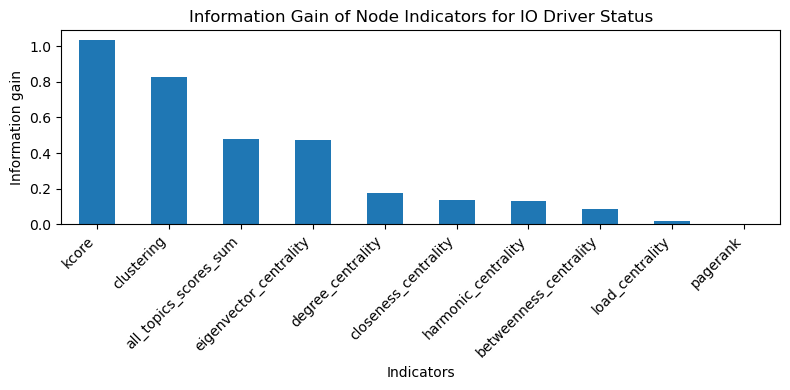

In [53]:
plot_indicators_information_gain(mi_series, folder_output_path, filename=f"{topic_col}_indicators_information_gain.png")

In [54]:

z_score_mi_series = compute_indicators_information_gain(node_indicators_zscore_df, io_authors_set)
plot_indicators_information_gain(z_score_mi_series, folder_output_path, filename=f"{topic_col}_indicators_z_score_information_gain.png" titel = "Information Gain of Node Indicators (Z-score) for IO Driver Status")

SyntaxError: invalid syntax. Perhaps you forgot a comma? (3201859222.py, line 2)

### Distributions

In [ ]:
def plot_indicators_distributions(
    node_indicators_df,
    output_path: str | Path | None = None,
    bins: int = 30,
):
    """Plot distributions of centrality features for all authors.

    Args:
        node_indicators_df: DataFrame (index=author, columns=centralities).
        output_path: If given, save figure to this folder path.
        bins: Number of histogram bins.
    """
    features = node_indicators_df.columns
    n = len(features)

    rows = 2
    cols = math.ceil(n / rows)

    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
    axes = axes.flatten()  # key fix

    for ax, feature in zip(axes, features):
        ax.hist(node_indicators_df[feature], bins=bins, alpha=0.8)
        ax.set_title(feature)
        ax.set_xlabel("Value")
        ax.set_ylabel("Counts")


    # remove unused axes (when n is odd)
    for ax in axes[n:]:
        ax.remove()

    plt.tight_layout()

    if output_path is not None:
        output_path = Path(output_path)
        distributions_output_path = output_path / "indicators_distributions.png"
        fig.savefig(distributions_output_path, dpi=300, bbox_inches="tight")
        print(f"Saved indicators distributions to: {distributions_output_path}")

    plt.show()
    plt.close(fig)

Saved indicators distributions to: ../results/Labeled_Datasets/Ecuador/Ecuador_part_all/2026_01_10/indicators_distributions.png


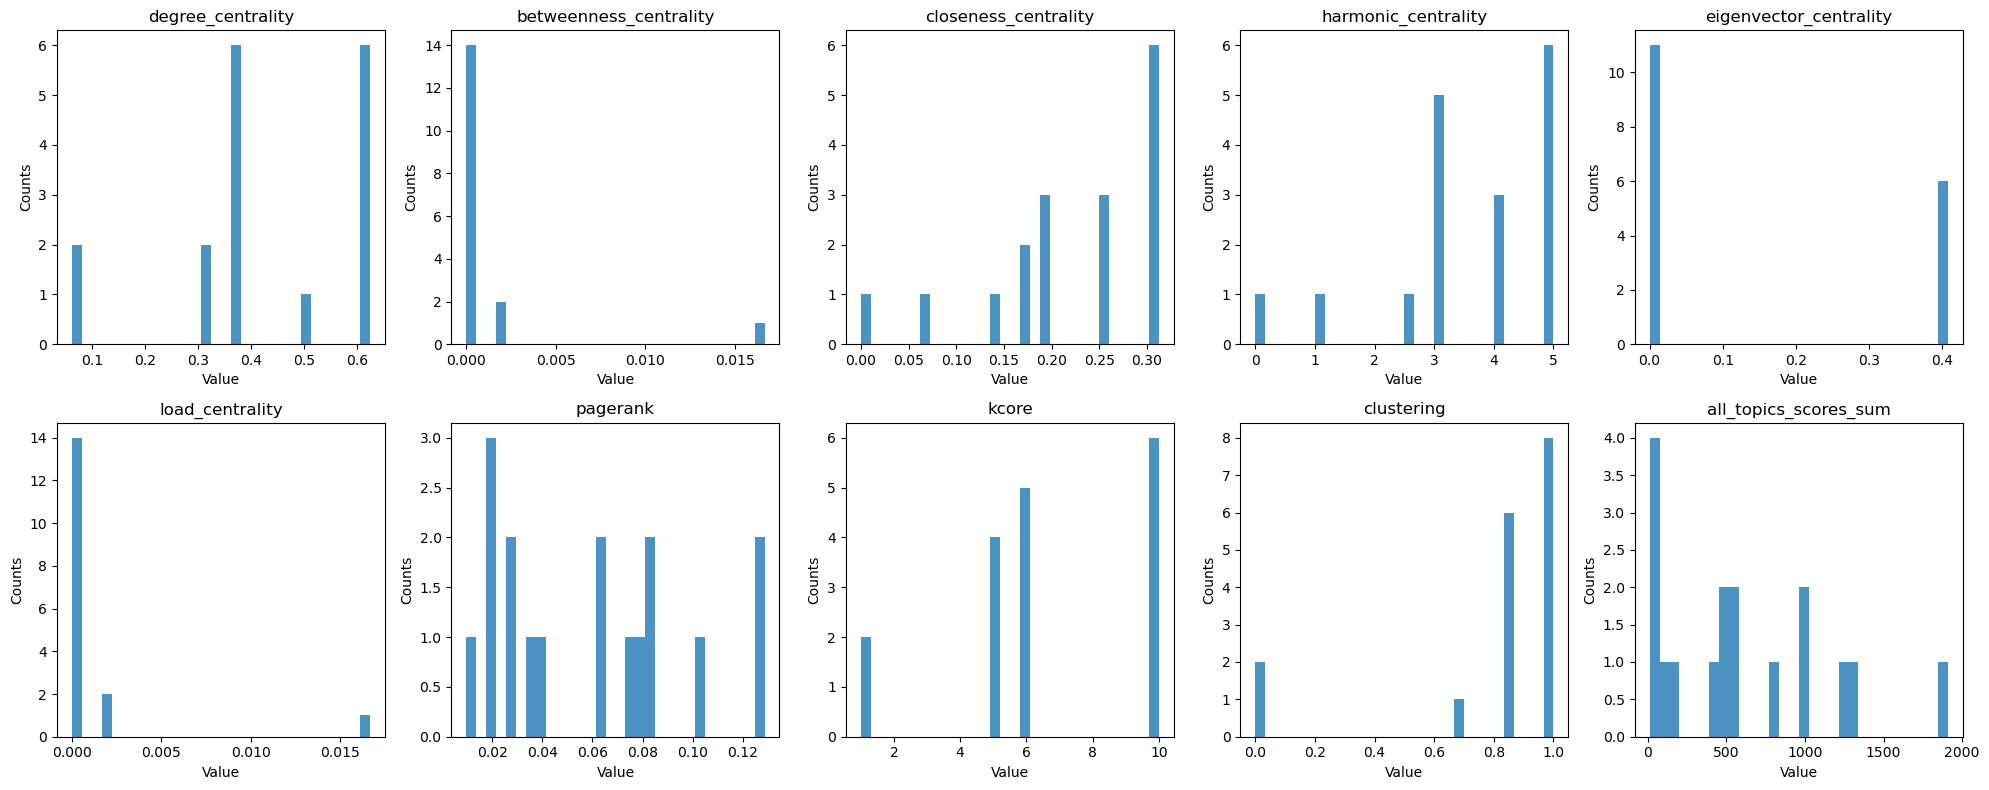

In [ ]:
plot_indicators_distributions(node_indicators_df, folder_output_path)

### Boxplots

In [ ]:
def plot_indicator_boxplots(node_indicators_df: pd.DataFrame, io_authors: set, output_path: str | Path= None) -> None:
    """Create box plots of each indicator grouped by IO status.

    Args:
        node_indicators_df: DataFrame indexed by author/accountid with indicator columns.
        io_authors: Set of IO author IDs.
        output_path: Optional path to save the plot image.
    """
    io_authors_set = set(map(str, io_authors))
    # idx_str = node_indicators_df.index.astype(str)

    plot_df = node_indicators_df.copy()

    io_mask = node_indicators_df.index.astype(str).isin(io_authors_set)
    plot_df["io_status"] = np.where(io_mask, "IO", "Non-IO")

    # Keep only numeric indicators
    indicators = [c for c in node_indicators_df.columns if is_numeric_dtype(node_indicators_df[c])]

    if not indicators:
        print("No numeric indicators found to plot.")
        return

    n = len(indicators)
    rows = 2 if n > 1 else 1
    cols = math.ceil(n / rows)

    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
    axes = [axes] if not isinstance(axes, (list, tuple, pd.core.generic.NDFrame)) and getattr(axes, "plot", None) else axes
    axes = getattr(axes, "flatten", lambda: axes)()

    for ax, ind in zip(axes, indicators):
        plot_df.boxplot(column=ind, by="io_status", ax=ax, grid=False)
        ax.set_title(ind)
        ax.set_xlabel("IO status")
        ax.set_ylabel(ind)

    # Remove unused axes
    for ax in axes[n:]:
        ax.remove()

    # Remove pandas' automatic "Boxplot grouped by io_status"
    fig.suptitle("Indicators vs IO status")
    plt.title("")  # clears the auto-title added by pandas
    plt.tight_layout(rect=[0, 0, 1, 0.95])


    if output_path is not None:
        output_path = Path(output_path)
        distributions_output_path = output_path / "indicators_indicator_boxplots.png"
        fig.savefig(distributions_output_path, dpi=300, bbox_inches="tight")
        print(f"Saved fig to: {distributions_output_path}")
    
    plt.show()
    plt.close()

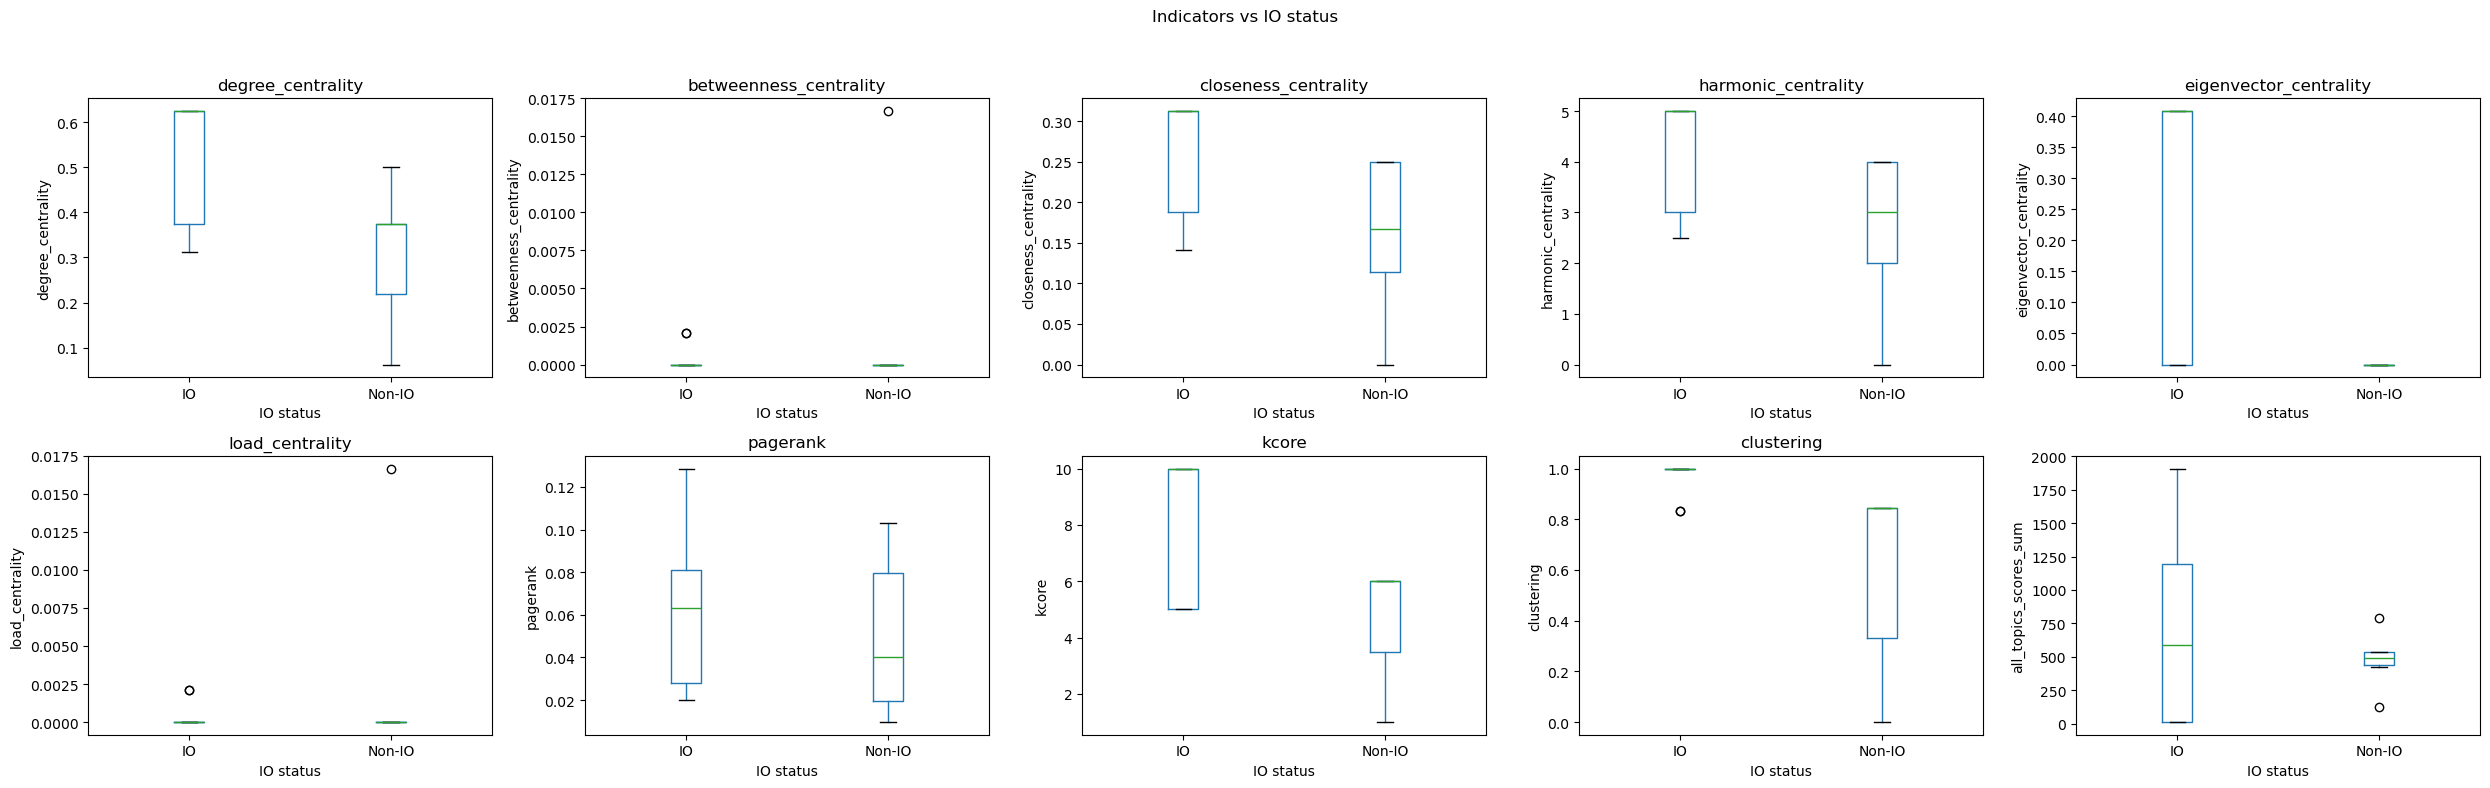

In [ ]:
plot_indicator_boxplots(node_indicators_df, io_authors_set)

# Parameter Sweep: Information Gain Analysis

This section implements functions to run key_authors_graph with different min_topic_size and top_n values, compute total information gain, and visualize results.

In [ ]:
# processed_df = pd.read_parquet("../results/Labeled_Datasets/Ecuador/Ecuador_part_all/2026_01_10/processed_Ecuador_part_all.gzip.parquet")
# print(f"processed_df shape {processed_df.shape}")
# print("processed_df columns:")
# print(processed_df.columns.tolist())

In [ ]:
from __future__ import annotations

from itertools import product
from typing import Iterable, Sequence

In [ ]:
def run_io_indicator_ig_experiment(
    df: pd.DataFrame,
    min_topic_size: int,
    top_n: int,
    account_relations: Iterable[tuple[str, str]],
    is_directed_graphs: bool,
    base_topic_col: str = "BERTopic_topic",
    author_col: str = "accountid",
    score_col: str = "topic_author_tfidf",
    is_io_control_col: str = "is_control",
    io_threshold: float = 0.33,
    min_posts: int = 5,
) -> pd.DataFrame:
    """Run a full IO experiment pipeline and return summary metrics.

    Pipeline:
      1) topic_col = f"{base_topic_col}_{min_topic_size}"
      2) get_io_authors_by_ratio(...) -> io_authors
      3) get_all_topics_key_authors(...) -> all_topics_key_authors_df
      4) build_accounts_graph(...) -> G
      5) compute_indicators(G) -> node_indicators_df
      6) compute_centrality_information_gain(...) -> IG per indicator
      7) return sum + mean IG.

    Returns:
        Single-row DataFrame with min_topic_size, top_n, is_directed_graphs,
        ig_sum, ig_mean (+ helpful counts).
    """
    # ---------- 0) topic_col ----------
    topic_col = f"{base_topic_col}_{min_topic_size}"
    if topic_col not in df.columns:
        raise KeyError(f"topic_col '{topic_col}' not found in df.columns")

    # ---------- 1) IO authors ----------
    io_authors = get_io_authors_by_ratio(
        df=df,
        author_col=author_col,
        is_io_control_col=is_io_control_col,
        io_threshold=io_threshold,
        min_posts=min_posts,
    )
    io_authors_set = set(map(str, io_authors))

    # ---------- 2) key authors ----------
    all_topics_key_authors_df = get_all_topics_key_authors(
        df=df,
        score_col=score_col,
        author_col=author_col,
        topic_col=topic_col,
        top_n=top_n,
    )

    # ---------- 3) build graph ----------
    G = build_accounts_graph(
        df=df,
        account_relations=account_relations,
        io_authors=io_authors,
        all_topics_key_authors_df=all_topics_key_authors_df,
        is_directed_graphs=is_directed_graphs,
    )

    # ---------- 4) compute indicators ----------
    node_indicators_df = compute_indicators(G)

    # ---------- 5) IG ----------
    ig_series = compute_indicators_information_gain(node_indicators_df, io_authors_set)
    ig_series = pd.to_numeric(ig_series, errors="coerce").dropna()

    ig_sum = float(ig_series.sum())
    ig_mean = float(ig_series.mean())

    # ---------- output ----------
    return pd.DataFrame([{
        "model": base_topic_col,
        "min_topic_size": int(min_topic_size),
        "top_n": int(top_n),
        "is_directed_graphs": bool(is_directed_graphs),
        "ig_sum": ig_sum,
        "ig_mean": ig_mean,
        "n_indicators": int(len(ig_series)),
        "n_nodes": int(node_indicators_df.shape[0]),
        "n_io_authors": int(len(io_authors_set)),
        "n_account_relations": int(len(account_relations)),
    }])

In [ ]:
def run_io_indicator_ig_grid(
    df: pd.DataFrame,
    min_topic_size_lst: Sequence[int],
    top_n_lst: Sequence[int],
    account_relations: Iterable[tuple[str, str]], # this is one configurations of account_relations.
    is_directed_graphs_lst: Sequence[bool] = (False, True),
    base_topic_col: str = "BERTopic_topic",
    author_col: str = "accountid",
    score_col: str = "topic_author_tfidf",
    is_io_control_col: str = "is_control",
    io_threshold: float = 0.33,
    min_posts: int = 5,
    output_folder_path: str | Path | None = None,
) -> pd.DataFrame:
    """Run run_io_indicator_ig_experiment over a grid of configurations.

    Args:
        df: Posts DataFrame.
        min_topic_sizes: List of min_topic_size values to test.
        top_n_lst: List of top_n values to test. top_n: Top-n authors per topic.
        account_relations: Relations used by build_accounts_graph.
        is_directed_graphs_lst: Which directed settings to test.
        base_topic_col, author_col, score_col, is_io_control_col, io_threshold, min_posts:
            Passed through to run_io_indicator_ig_experiment.
        output_folder_path: Optional path to save output files.

    Returns:
        Merged DataFrame of all runs, with a num_of_configuration column (1..N).
    """
    grid_results: list[pd.DataFrame] = []

    for cfg_idx, (min_topic_size, top_n, is_directed) in enumerate(
        product(min_topic_size_lst, top_n_lst, is_directed_graphs_lst), # all possible combinations
        start=1,
    ):
        results = run_io_indicator_ig_experiment(
            df=df,
            min_topic_size=int(min_topic_size),
            top_n=int(top_n),
            account_relations=account_relations,
            is_directed_graphs=bool(is_directed),
            base_topic_col=base_topic_col,
            author_col=author_col,
            score_col=score_col,
            is_io_control_col=is_io_control_col,
            io_threshold=io_threshold,
            min_posts=min_posts,
        )
        results["configuration_number"] = cfg_idx
        grid_results.append(results)


    out = pd.concat(grid_results, ignore_index=True) # merge

    # Ordering
    sort_cols = [c for c in ["min_topic_size", "top_n", "is_directed_graphs"] if c in out.columns]
    if sort_cols:
        out = out.sort_values(sort_cols).reset_index(drop=True)

    # Save
    if output_folder_path is not None:
        output_folder_path = Path(output_folder_path)
        grid_output_path = output_folder_path / "io_indicator_ig_experiment_grid_results.parquet"
        out.to_parquet(grid_output_path, index=False, compression="gzip")
        print(f"Saved grid results to: {grid_output_path}")

    return out

In [55]:
grid_df = run_io_indicator_ig_grid(
    df=df,
    min_topic_size_lst=[512],
    top_n_lst=[10, 20],
    account_relations=account_relations,
    is_directed_graphs_lst=[False, True],
)
display(grid_df)

NameError: name 'run_io_indicator_ig_grid' is not defined